# ACCESS-CM3 SST and SST difference from WOA23

Related issue: https://github.com/ACCESS-Community-Hub/access-om3-25km-paper-1/issues/9

In [64]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-figs/


In [65]:
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import cftime
import os
import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
from textwrap import wrap
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

In [66]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39077 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/39077/status,
Dashboard: /proxy/39077/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36533,Workers: 0
Dashboard: /proxy/39077/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33311,Total threads: 1
Dashboard: /proxy/36687/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:45253,


### Define plot function

In [67]:
blue_marble = plt.imread('/g/data/ik11/grids/BlueMarble.tiff')
blue_marble_extent = (-180, 180, -90, 90)

In [68]:
def plot(dat, title=None, **kwargs):
    if title is None:
        title = dat.attrs['long_name']
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))
    dat.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={"label": "\n".join(wrap(f"{dat.attrs['long_name']} [{dat.attrs['units']}]", 45)),
                     "fraction": 0.03, "aspect": 15, "shrink": 0.7},
        **kwargs
    )
    
    # Add blue marble land:
    ax.imshow(
        blue_marble, extent=blue_marble_extent, transform=ccrs.PlateCarree(), origin="upper"
    )
    
    plt.title(title);

### Load and plot data from ACCESS-CM3

In [69]:
exptname=os.path.basename(os.path.dirname(esm_file))

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

In [70]:
exptname

'cm3-demo-datastore'

In [71]:
geolon = datastore.search(variable="geolon").to_dask().geolon
geolat = datastore.search(variable="geolat").to_dask().geolat

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:99: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:99: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime obje

In [72]:
variable = "tos"
model_all = datastore.search(variable=variable, frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
)[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [73]:
# for IAF
model_all = model_all.convert_calendar("proleptic_gregorian", use_cftime=True)

In [74]:
model_all.time.values[0] # initial date in data

cftime.DatetimeProlepticGregorian(1981, 1, 16, 12, 0, 0, 0, has_year_zero=True)

In [75]:
model_all.time.values[-1] # final date in data

cftime.DatetimeProlepticGregorian(2030, 12, 16, 12, 0, 0, 0, has_year_zero=True)

In [76]:
# set time range

# timerange = slice(cftime.DatetimeNoLeap(1942, 1, 1, 0, 0, 0, 0),
#                   cftime.DatetimeNoLeap(1952, 1, 1, 0, 0, 0, 0))
# timerange = slice(None, None)
# datestop = model_all.time.values[-1] # final date in data
datestop = cftime.DatetimeProlepticGregorian(2018, 12, 14, 12, 0, 0, 0, has_year_zero=True)  # to match OM2 IAF run
datelist = list(cftime.to_tuple(datestop))
datelist[0] -= 10  # last 10 years
datestart = cftime.datetime(*datelist, calendar=datestop.calendar)
timerange = slice(datestart, datestop)

In [77]:
datestart

cftime.datetime(2008, 12, 14, 12, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True)

In [78]:
datestop

cftime.DatetimeProlepticGregorian(2018, 12, 14, 12, 0, 0, 0, has_year_zero=True)

In [79]:
model_all = model_all.sel(time=timerange)

In [80]:
%%time
model = model_all.mean('time').load()

CPU times: user 512 ms, sys: 341 ms, total: 853 ms
Wall time: 1.2 s


In [81]:
model = model.pint.quantify().pint.to('C').pint.dequantify()

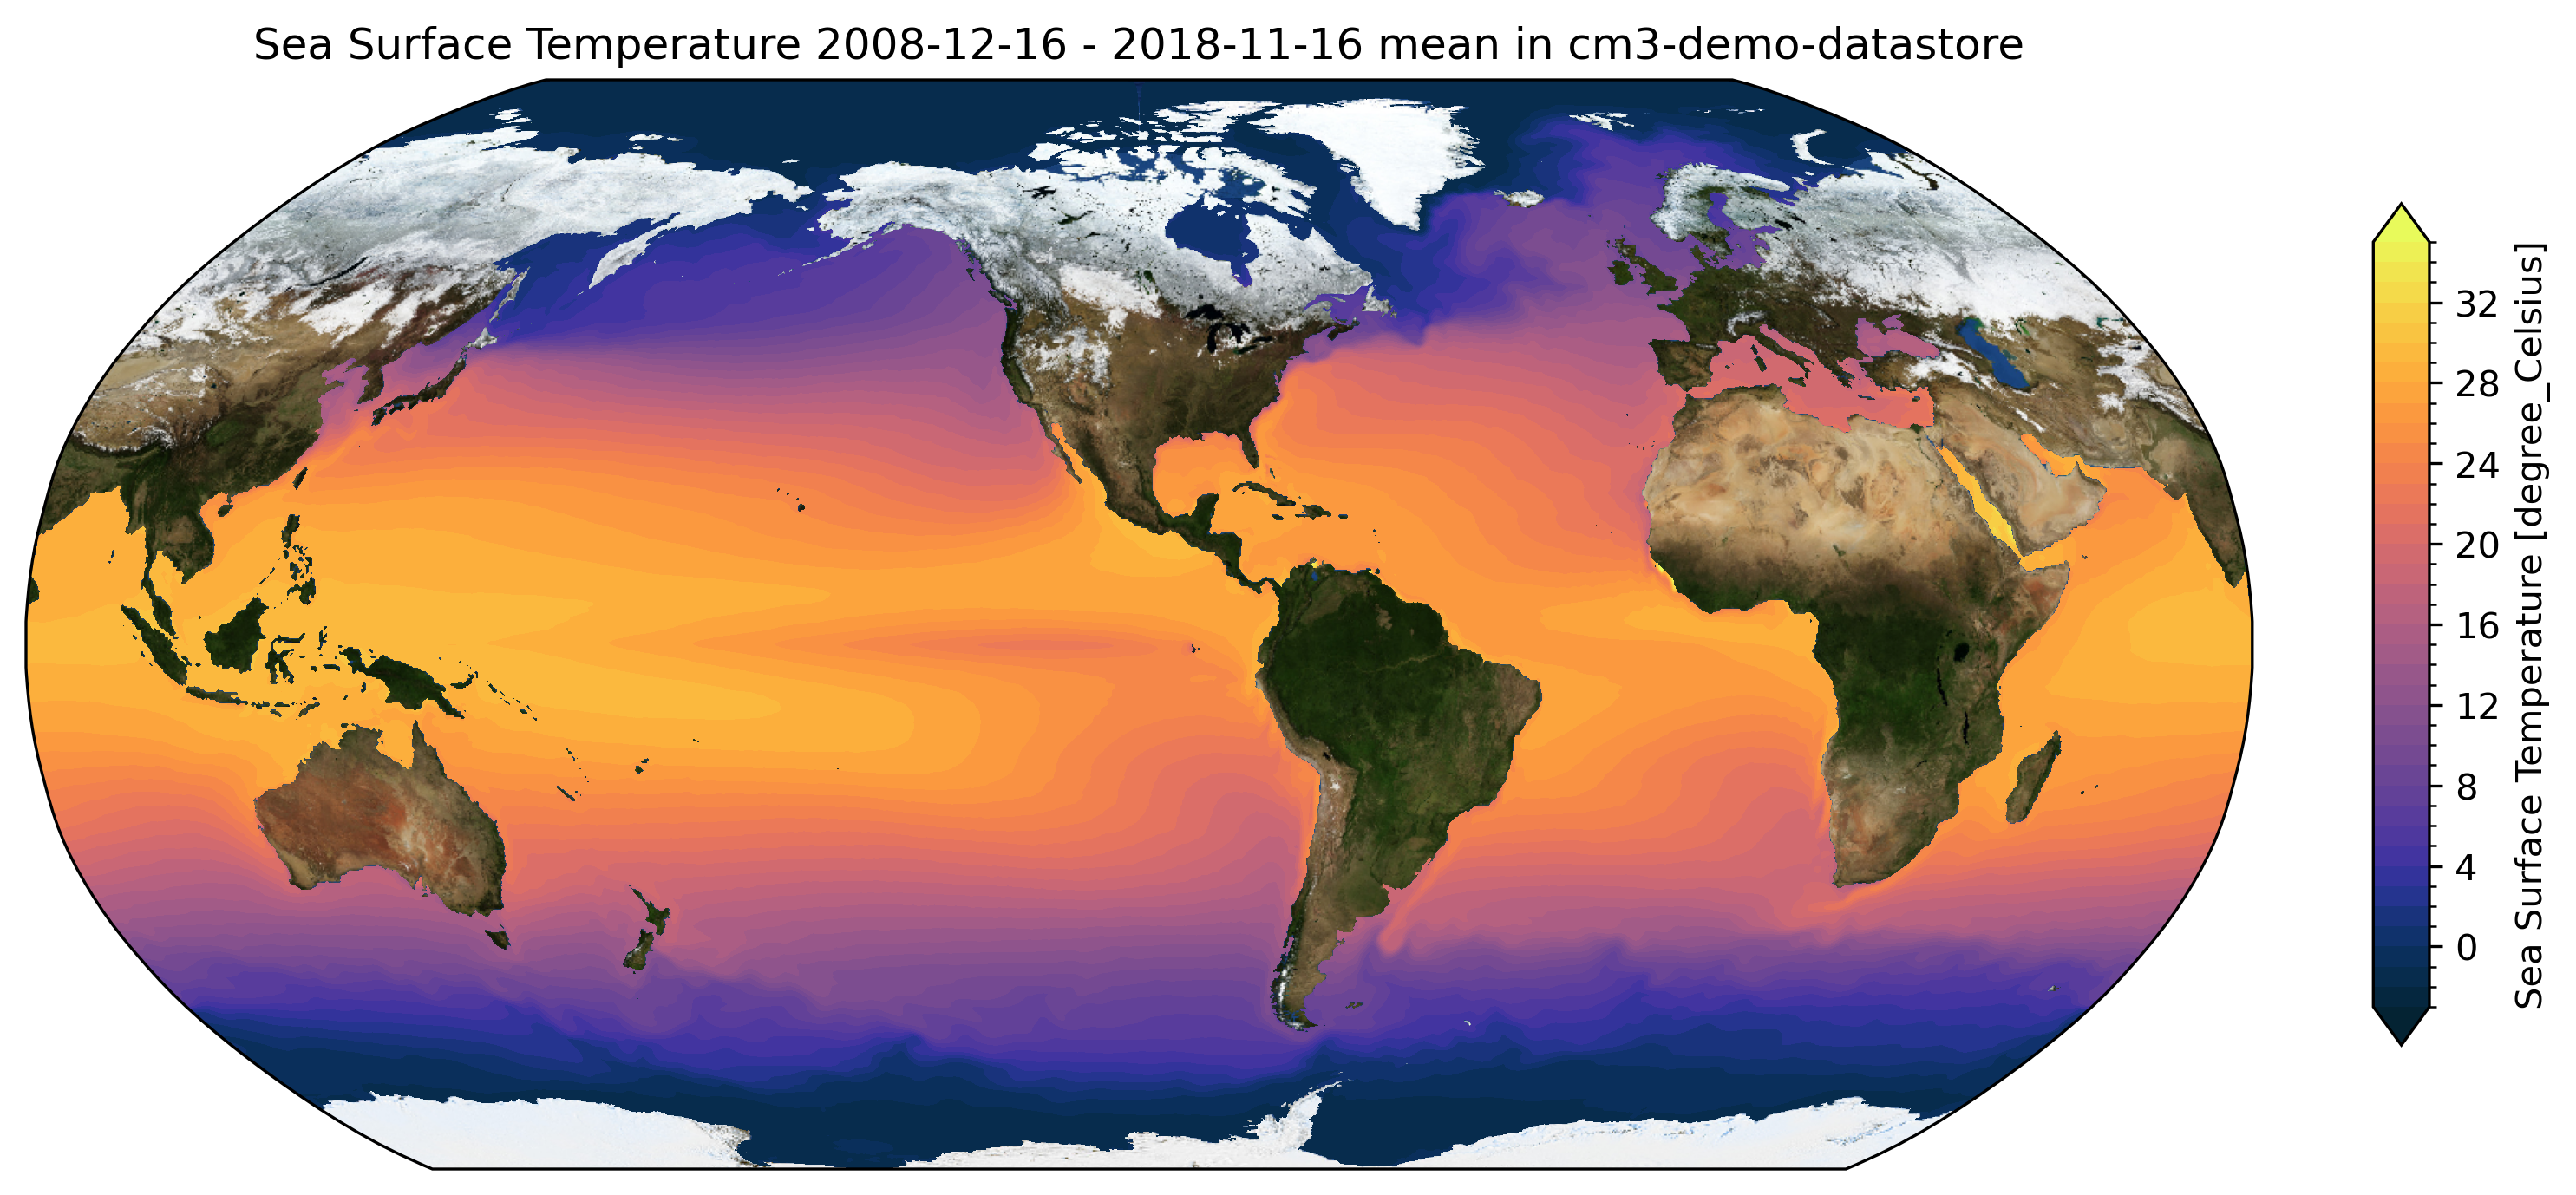

In [82]:
plot(model,
    levels=39,
    vmin=-3,
    vmax=35,
    extend="both",
    cmap=cm.cm.thermal,
    title=f"{model.attrs['long_name']} {model_all.time.values[0].strftime('%Y-%m-%d')} - {model_all.time.values[-1].strftime('%Y-%m-%d')} mean in {exptname}"
    )

### Load data from WOA23 (annual mean; Jan is ACCESS-OM3 initial condition)

In [83]:
obs = xr.open_mfdataset('/g/data/ik11/inputs/access-om3/woa23/025/2025.08.26/woa23_ts_*', 
                            chunks={'time': -1}
                       )['temp'].isel(depth=0).mean('time').rename({'lat': 'yh', 'lon': 'xh'}).load()

In [84]:
##### ONLY NEEDED FOR 25km-iaf-test-for-AK-expt-7df5ef4c !!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# omit latitudes with grid bug https://github.com/ACCESS-NRI/ocean_model_grid_generator/issues/7
obs = obs.isel(yh=slice(10, None))

In [85]:
obs = obs.cf.assign_coords({ "longitude": geolon, "latitude": geolat })

### Plot ACCESS-CM3 minus WOA23
First plot full range, then a sequence at specified ranges.

**BUG? is WOA initial condition data conservative temperature, but model data potential temperature? - CHECK!**

In [86]:
bias = (model - obs).load().cf.assign_coords({ "longitude": geolon, "latitude": geolat })

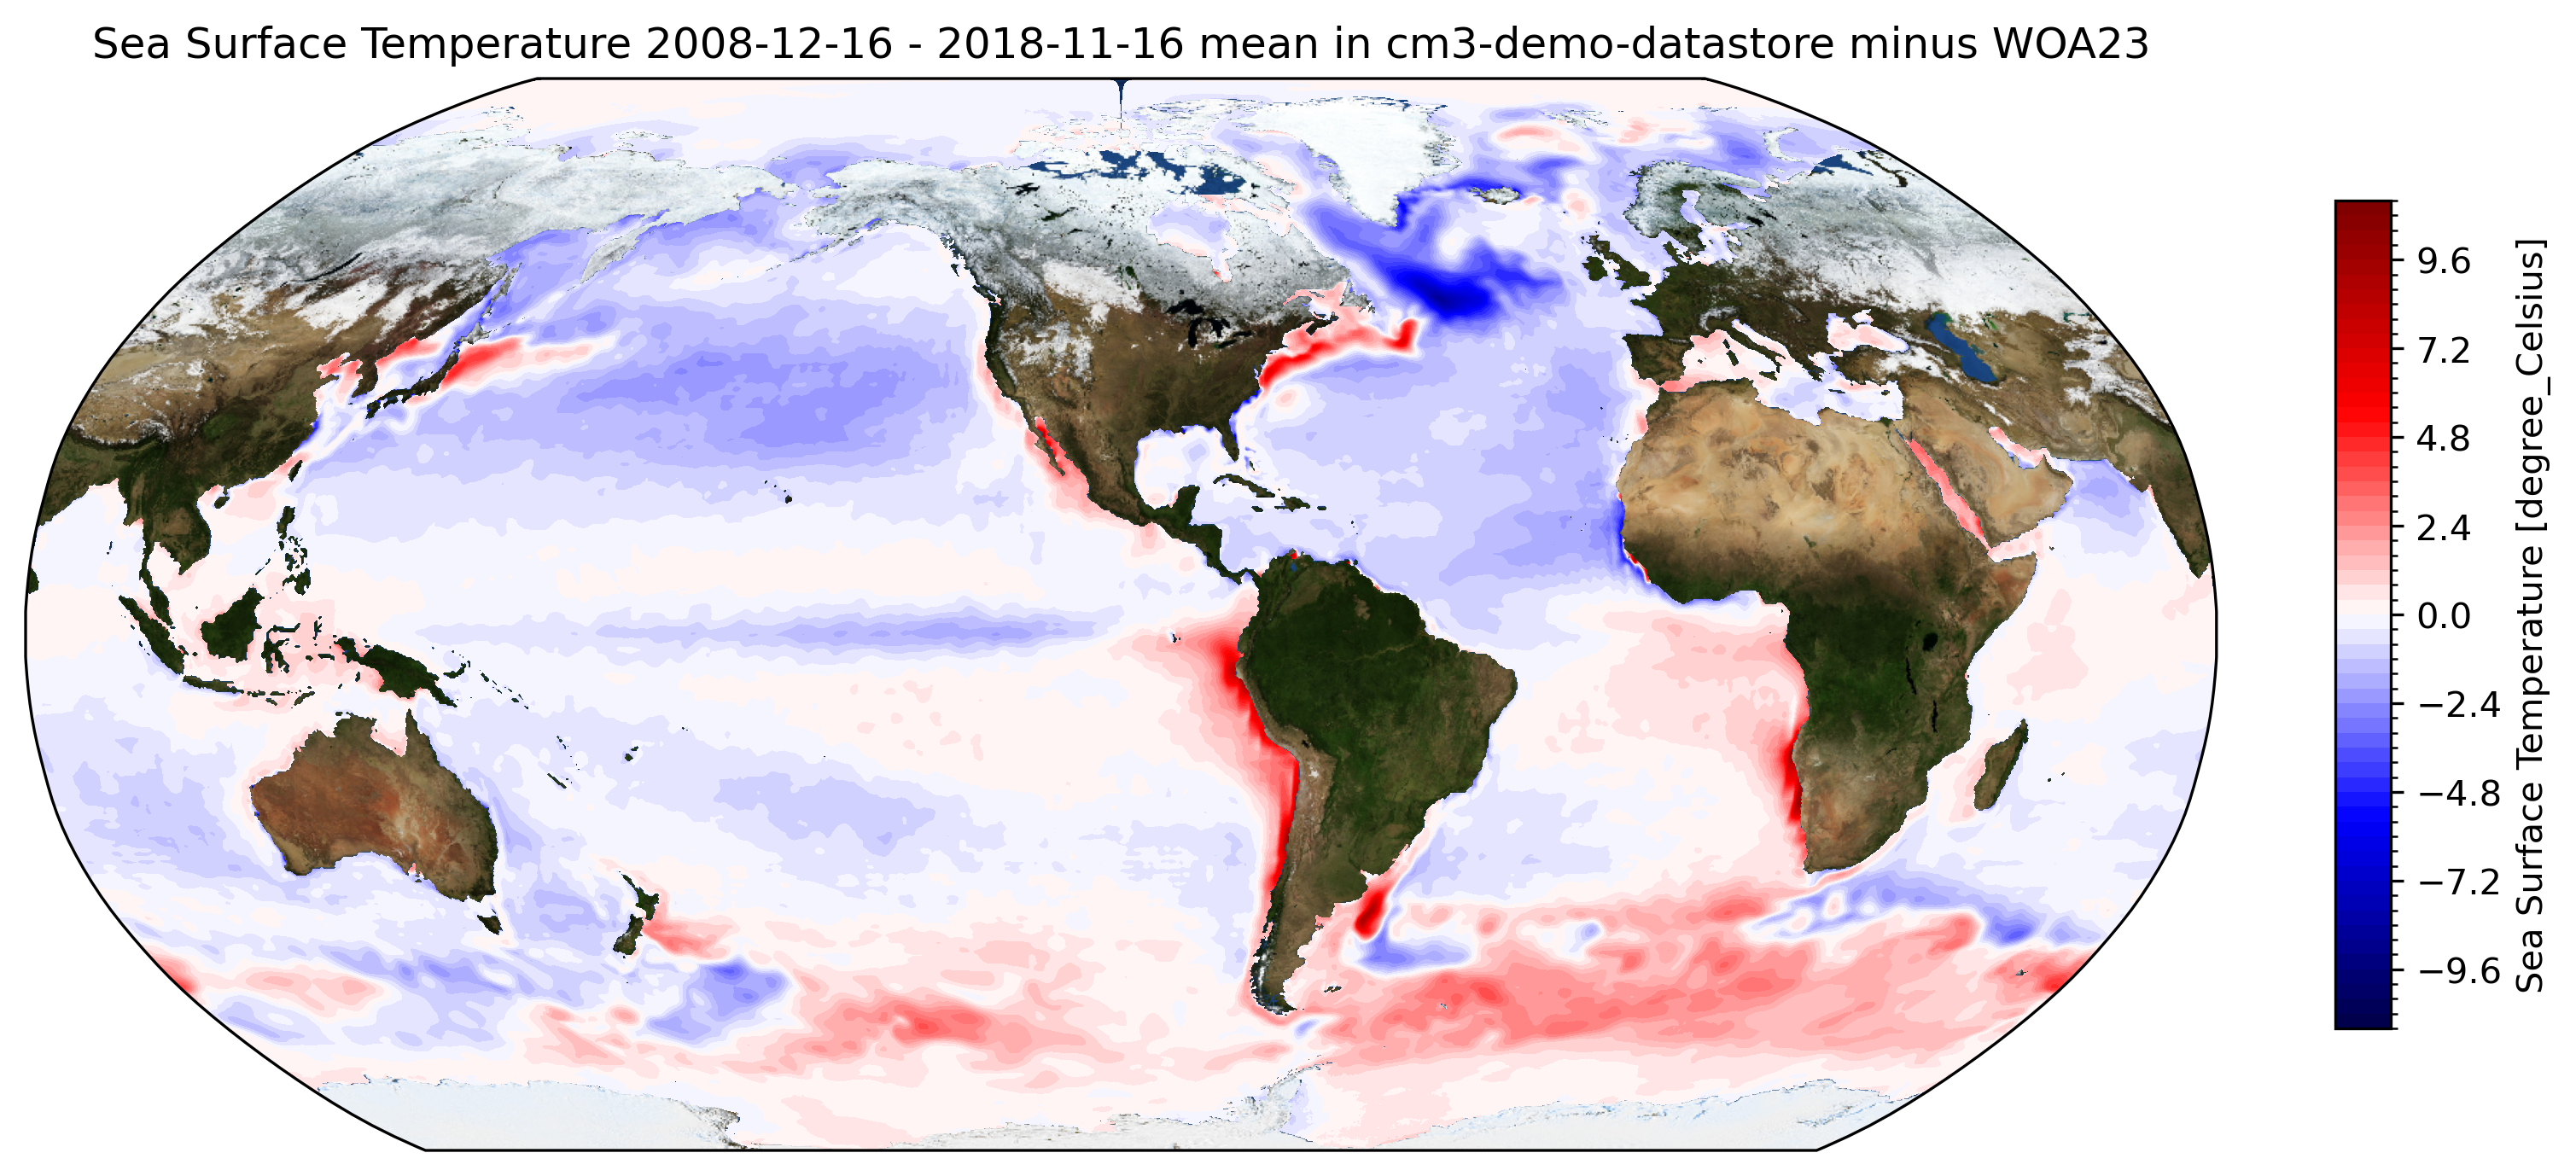

In [87]:
plot(bias,
    levels=61,
    cmap='seismic',
    title=f"{model.attrs['long_name']} {model_all.time.values[0].strftime('%Y-%m-%d')} - {model_all.time.values[-1].strftime('%Y-%m-%d')} mean in {exptname} minus WOA23"
    )

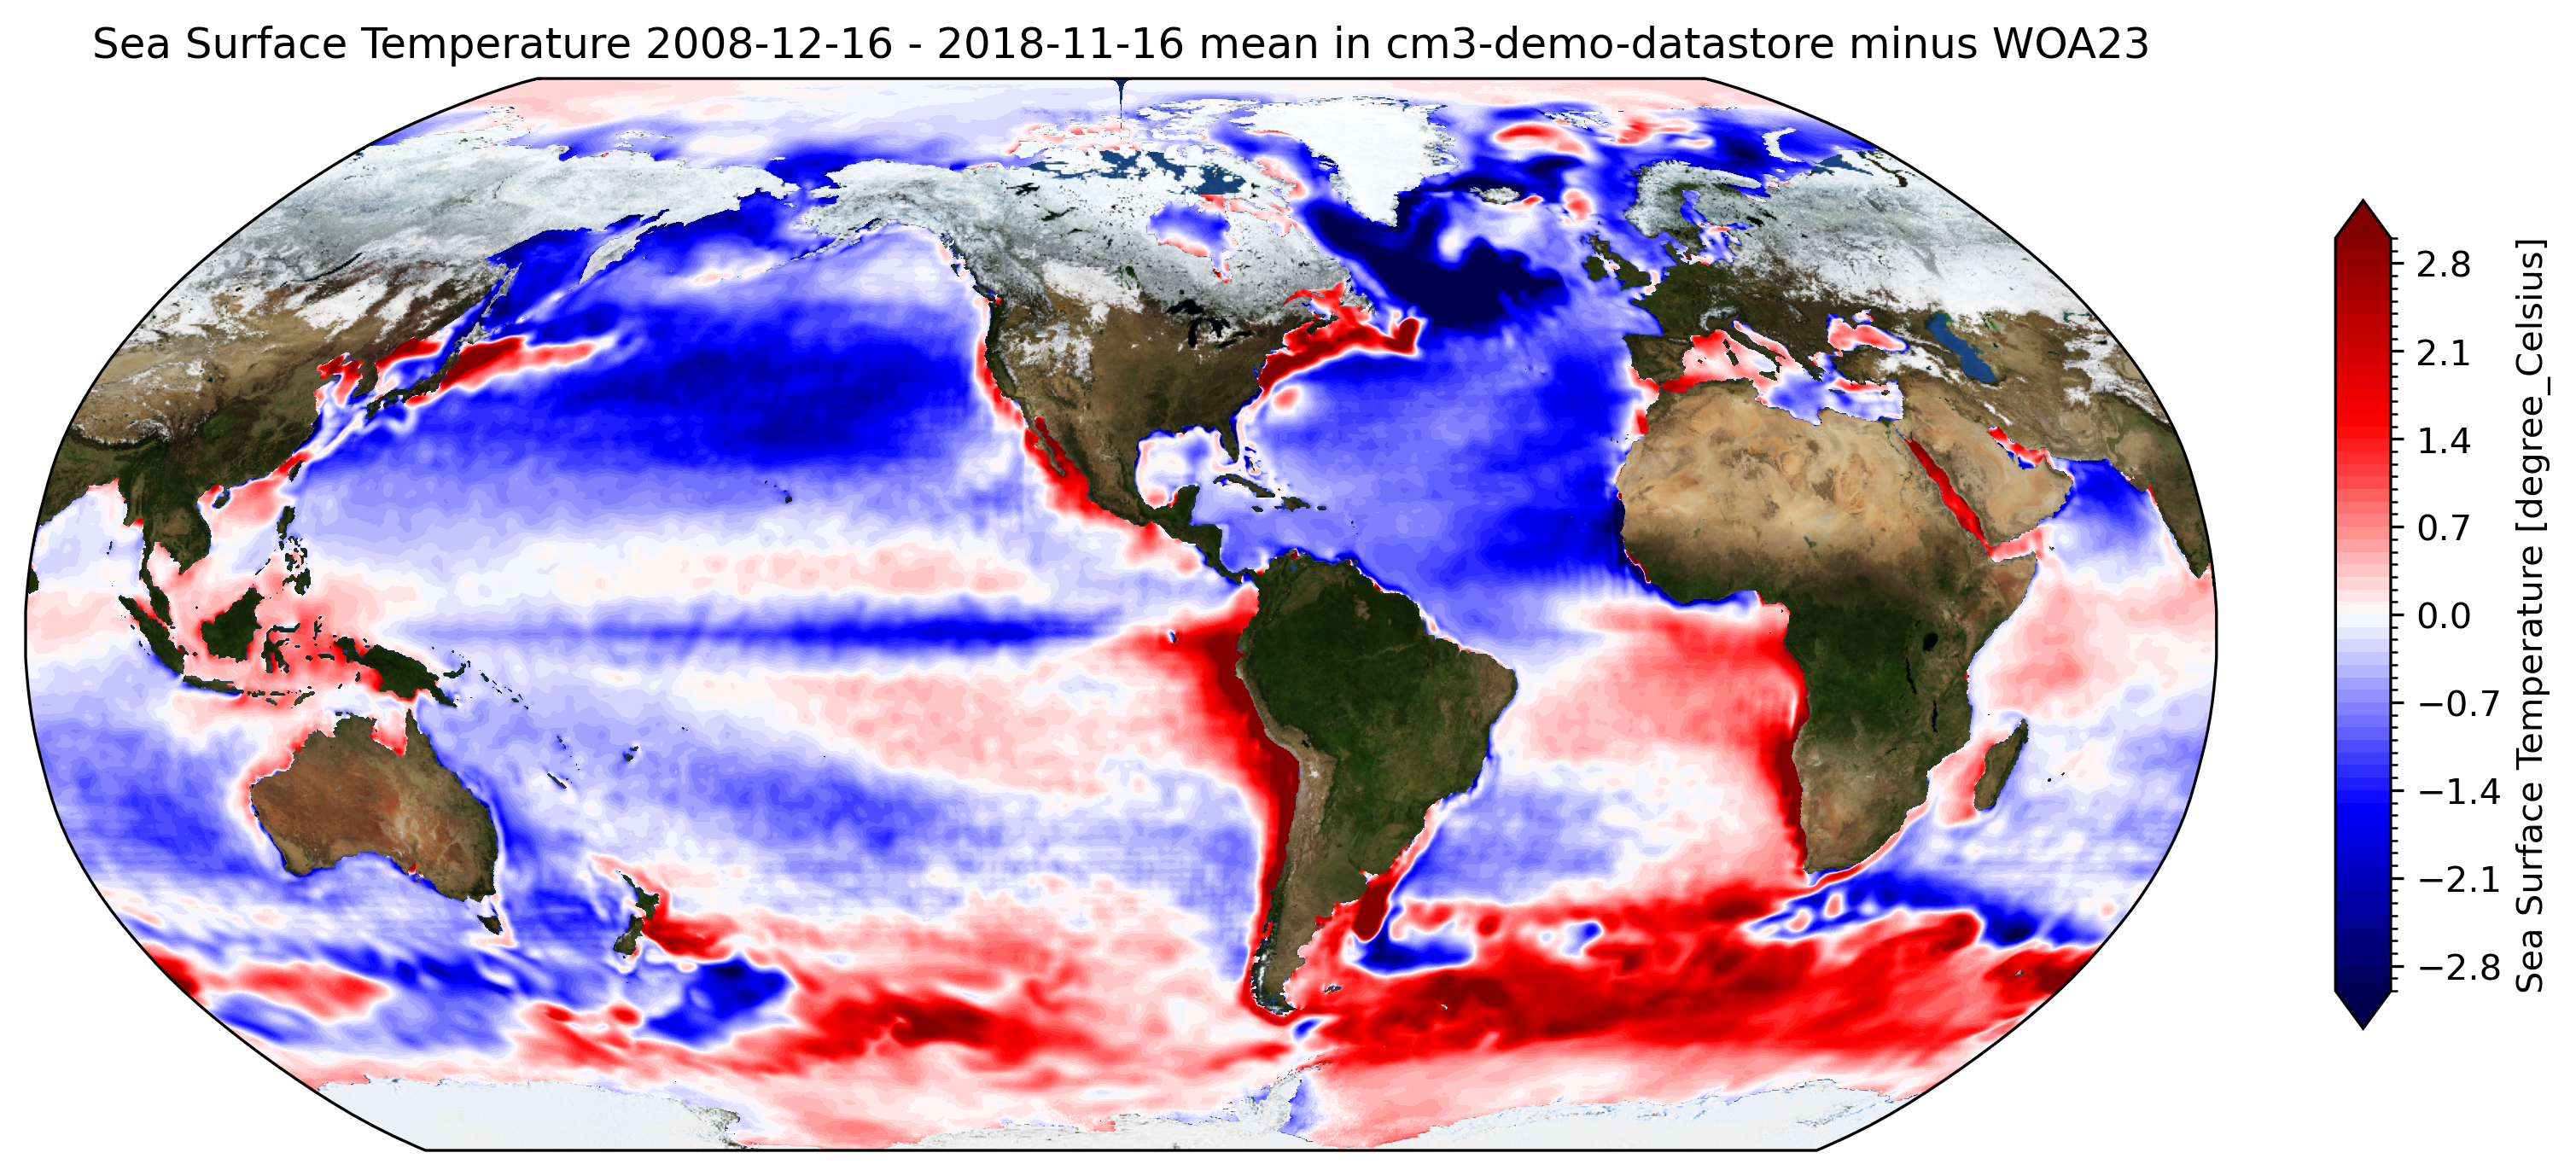

In [88]:
plot(bias,
    levels=61,
    vmin=-3,
    vmax=3,
    extend="both",
    cmap='seismic',
    title=f"{model.attrs['long_name']} {model_all.time.values[0].strftime('%Y-%m-%d')} - {model_all.time.values[-1].strftime('%Y-%m-%d')} mean in {exptname} minus WOA23"
    )

In [89]:
client.close()